In [ ]:
#loading the dictionary from another file
import json

with open("consensus_dict.json", "r") as f:
    consensus_dict = json.load(f)

print(consensus_dict)

def hamming_dist(seq1, seq2):
    return sum(a != b for a, b in zip(seq1, seq2))


{'IGKV1': 'MD_K___IHNHHK___________________DIQMTQSPSSLSASVGDRVTITCRASQ___Y_______L_WYQQKPGKAPKLLIY_AST_L_SGVPSRFSSRATLTGSGSGTDFTLTISSLQPEDFATYYCQQ__________TFG_GTKVEIKR_T_VAAPSVFIFS__PPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECS__________QLIMVTNKAIASQ', 'IGLV1': 'MGILPSPGM_______L_L_____G__S_QSVLTQPPS_S__PGQRVTISC_GS_SNLY_NIG____V_WYQQQLPG_APKLLIY____RPSGVPDRFSGSKSGSSTSASLAI_GLQ_EDEADYYC___D_SL_____VFGGGTK_TVL_TKLTVLGQPKAAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGSVETTTPSKQSNNKYAASSYLSLTPEQWKSHRSYSCQVTHEGSSSTVEKTVAPTECSAAENLYFQGS', 'IGKV3': 'PNITNLCP____________L_________NCVAEIV_TQSP_TLSLSPGERATLSCRASQSV___DLCFTNVYA_______LAWYQQKPGQAPRLLIY_AS_RATGIP_RFSGSGSGTDFTLTIS_LEPEDFAVYYCQQ____PS____TFG_GTKVQ_EIKRT___PTVSIFPPSSEQLTSGGASVVCFTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC____Q______TNGVGY_______LS_A_________C__T__GL____________H', 'IGKV6': 'DIV_TQ___F_S_S____V_ITC_ASQ_

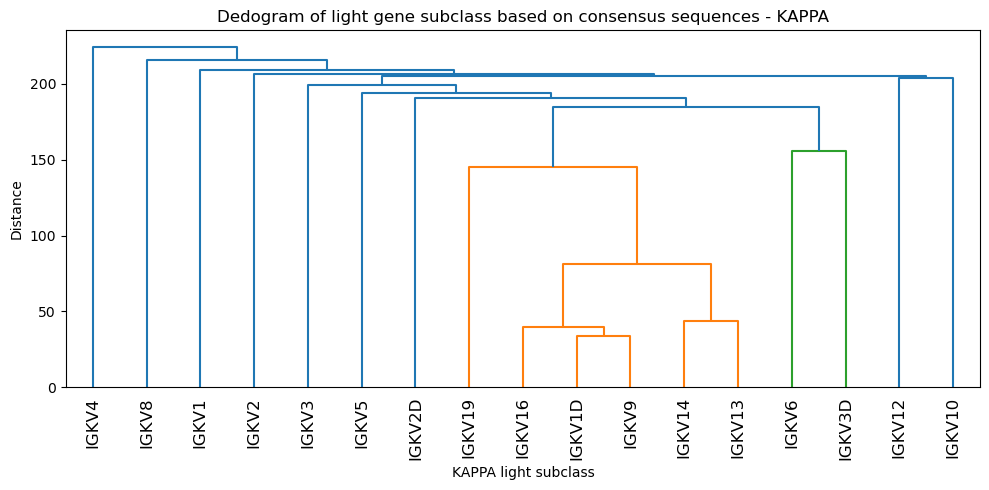

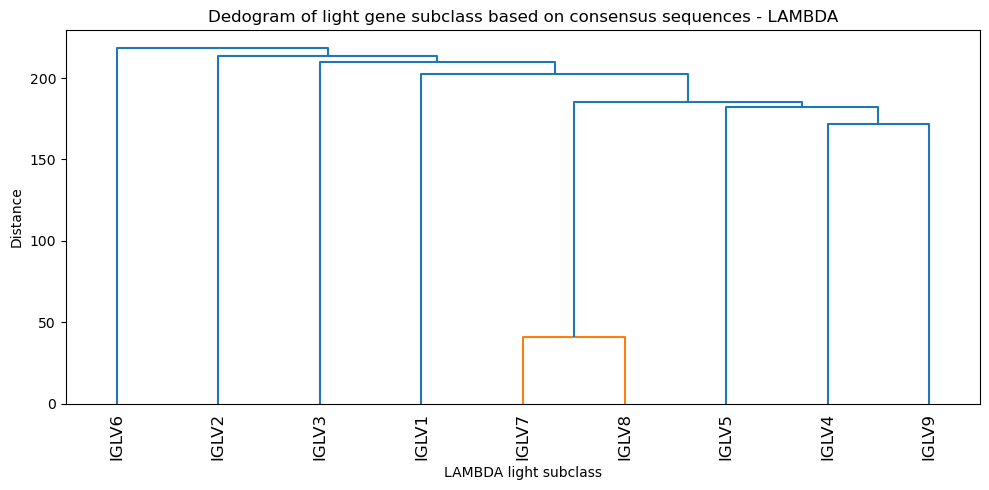

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

#split the kappa and lambda dictionaries 
kappa_consensus = {k: v for k, v in consensus_dict.items() if 'k' in k.lower()}
lambda_consensus = {k: v for k, v in consensus_dict.items() if 'l' in k.lower()}

max_len = max(len(seq) for seq in consensus_dict)

#padding the consensus sequences to the same lenght by adding '_' as an extention 
def pad(seq, length):
    return seq + "_" * (length - len(seq))

#saving padded consensus sequences
kappa_consensus_padded = {k: pad(v, max_len) for k, v in kappa_consensus.items()}
lambda_consensus_padded = {k: pad(v, max_len) for k, v in lambda_consensus.items()}

#defining function to cluster and plot both lambda and kappa sequences separately 
def cluster_and_plot(consensus_dict, title_prefix= ""):
   
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())

    dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    linkage_matrix = linkage(squareform(dist_matrix), method="average")

    plt.figure(figsize=(10, 5))
    dendrogram(linkage_matrix, labels=labels, leaf_rotation=90)
    plt.title(f"Dedogram of light gene subclass based on consensus sequences - {title_prefix}")
    plt.ylabel("Distance", fontsize=10)
    plt.xlabel(f"{title_prefix} light subclass", fontsize=10)
    plt.tight_layout()
    plt.show()

cluster_and_plot(kappa_consensus_padded, title_prefix="KAPPA")
cluster_and_plot(lambda_consensus_padded, title_prefix="LAMBDA")